## Script for Testing Segmentation CNN

## Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, f1_score
from matplotlib import pyplot as plt
from scipy.signal import resample_poly
from math import gcd
import pickle
import random
from scipy.ndimage import uniform_filter1d

from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Input, UpSampling1D, Concatenate,Dropout
from tensorflow.keras.models import Model

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)



## Loading in Data

In [ ]:
features_all = pd.read_pickle("training_features_18042026.pkl")
features_all_temp = features_all
features_all = features_all[~((features_all["Subject"] == "RL03JG") & (features_all["Nap Number"] == 5))] # presentation for this subject is 0 ? somethign weird 

labels = pd.read_pickle("segments.pkl")

print("==========SANITY CHECK==========")
print("Nap IDs align? ", (labels["Nap_ID"].values == features_all["Nap Number"].values).all())
print("Subject rows align? ", (labels["Subject"].values == features_all["Subject"].values).all())


==========SANITY CHECK==========
Nap IDs align?  True
Subject rows align?  True


In [120]:
# concatenate dfs
features_all = features_all.reset_index(drop=True)
labels = labels.reset_index(drop=True)

features_all = pd.concat([features_all, labels], axis=1)  

## Functions

### Pre-processing functions 

In [4]:
def to_one_hot(y, num_classes=2):
    """
    Convert binary labels to one-hot encoding.
    Input:  (samples, timesteps, 1)  — values 0 or 1
    Output: (samples, timesteps, num_classes)
    """
    y_squeezed = y[..., 0].astype(int)          # (14280, 2248)
    return np.eye(num_classes)[y_squeezed]  

In [5]:
def iou_metric(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred > threshold).astype(int)
    intersection = np.logical_and(y_true, y_pred_bin).sum()
    union = np.logical_or(y_true, y_pred_bin).sum()
    return intersection / union

In [6]:
def weighted_bce(y_true, y_pred):
    global pos_weight
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) * (
        y_true * pos_weight + (1 - y_true)
    )

In [7]:
# function for resampling time series data to sampling frequency of epochs 
def resample_timeseries(X, orig_fs, target_fs):

    g = gcd(orig_fs, target_fs)
    up   = target_fs // g   # upsample factor
    down = orig_fs   // g   # downsample factor

    resampled = resample_poly(X, up, down, axis=-1)

    # fix weirdness caused by resampling 
    resampled = (resampled >= 0.5).astype(int)[0:len(resampled)] 
    
    return resampled

In [397]:
def plot_random_epoch(df,random=True,subject=None,epoch=None,nap_id=None):
    """
    Randomly selects a Subject, Nap_ID, and epoch and plots:
    - Zygo + Contractions Zygo (subplot 1)
    - Corr + Contractions Corr (subplot 2)
    """

    # Random selection
    if random: 
        subject_list = df.loc[:, ~df.columns.duplicated()]
        subject = np.random.choice(subject_list["Subject"].unique())

        
        nap_id   = np.random.choice(sub_df["Nap Number"].unique())
        epoch    = np.random.randint(0, 60)
    else:
        subject = subject 
        epoch = epoch -1
        nap_id = nap_id 
    
    
    sub_df  = df[df.iloc[:, 0] == subject]  
    nap_df   = sub_df[sub_df["Nap_ID"] == nap_id]
    # Extract the signals for that epoch
    zygo             = nap_df["Zygo"].values[epoch][:-1]
    zygo_cont        = nap_df["Contraction Zygo"].values[epoch][:-1]
    corr             = nap_df["Corr"].values[epoch][:-1]
    corr_cont        = nap_df["Contraction Corr"].values[epoch][:-1]

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"Subject: {subject} | Nap: {nap_id} | Epoch: {epoch+1}", fontsize=13)

    axes[0].plot(zygo,      label="Zygo",             color="steelblue")
    axes[0].plot(zygo_cont*75, label="Contraction Zygo", color="tomato")
    axes[0].set_ylabel("Zygo")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(corr,      label="Corr",             color="steelblue")
    axes[1].plot(corr_cont*75, label="Contraction Corr", color="tomato")
    axes[1].set_ylabel("Corr")
    axes[1].set_xlabel("sampels")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Usage

### Convolution functions 

In [9]:
def unet_1d(epoch_len, feature_num, num_classes):
    inputs = Input(shape=(epoch_len, feature_num))

    # Encoder
    e1 = Conv1D(32, kernel_size=3, padding='same', activation='relu',kernel_regularizer=l2(0.001))(inputs)
    e1 = Dropout(0.4)(e1)  # bump up from 0.3
    p1 = MaxPooling1D(pool_size=2)(e1)

    e2 = Conv1D(64, kernel_size=3, padding='same', activation='relu',
            kernel_regularizer=l2(0.001))(p1)
    e2 = Dropout(0.4)(e2)
    p2 = MaxPooling1D(pool_size=2)(e2)

    # Bottleneck
    b = Conv1D(128, kernel_size=3, padding='same', activation='relu')(p2)

    # Decoder
    u1 = UpSampling1D(size=2)(b)
    u1 = Concatenate()([u1, e2])
    d1 = Conv1D(64, kernel_size=3, padding='same', activation='relu')(u1)

    u2 = UpSampling1D(size=2)(d1)
    u2 = Concatenate()([u2, e1])
    d2 = Conv1D(32, kernel_size=3, padding='same', activation='relu')(u2)

    
    # Output
    # outputs = Conv1D(num_classes, kernel_size=1, activation='sigmoid')(d2) numclasses = 1 single output neuron 
    outputs = Conv1D(num_classes, kernel_size=1, activation='softmax')(d2) # numclasses = 2 two output neurons (contraction vs no contraction)

    # dense layer for output 
    
    return Model(inputs, outputs)

In [10]:
def run_kfold_training(model_func,X_train_full, X, y,  input_shape, num_classes, feature_num,compile_kwargs, fit_kwargs=None, # arguments fed to model.fit() 
                       n_splits=5,random_state=42, shuffle=True, verbose=1,epoch_num=10,
                         type=1,): # model type (1: single head count, 2: two head count and duration, 3: two head for zygo and corr, 4: four head) 
   # returns a dictionary with {"models", "histories", "cv_scores"}.     

    if fit_kwargs is None:
        fit_kwargs = {}
    fit_kwargs = fit_kwargs.copy()

 

    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    models = []
    histories = []
    cv_scores = []

    fold = 1
    for train_idx, val_idx in kf.split(X_train_full):
        print(f"Fold: {fold} {'='*65}")
        # X_train, X_val = X[train_idx], X[val_idx]
        # y_train, y_val = y[train_idx], y[val_idx]
        X_train = np.array(X_train_full[train_idx], dtype=np.float32)
        X_val = np.array(X_train_full[val_idx], dtype=np.float32)
        y_train = np.array(y[train_idx], dtype=np.float32)
        y_val = np.array(y[val_idx], dtype=np.float32)

 
        model = model_func(input_shape, feature_num,num_classes)
        model.compile(**compile_kwargs)

  
        if type ==2:

            history = model.fit(
                    X_train,
                    {"count_output": y_train[:, 0],
                    "duration_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "count_output": y_val[:, 0],
                        "duration_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    verbose=verbose,
                )
            
            scores = model.evaluate(X_val, {
                                    "count_output": y_val[:, 0],
                                    "duration_output": y_val[:, 1],
                                    }, 
                                    return_dict=True)
            
        elif type == 3:
            history = model.fit(
                    X_train,
                    {"zygo_output": y_train[:, 0],
                    "corr_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "zygo_output": y_val[:, 0],
                        "corr_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    )
            
            scores = model.evaluate(X_val, {
            "zygo_output": y_val[:, 0],
            "corr_output": y_val[:, 1],
                },return_dict=True)
            
        elif type == 4:
              history = model.fit(X_train, {
                        'zygo_count_output': y_train[:, 0],
                        'zygo_duration_output': y_train[:, 1],
                        'corr_count_output': y_train[:, 2],
                        'corr_duration_output': y_train[:, 3]
                    }, epochs=epoch_num, validation_data=(
                    X_val,
                    {
                        'zygo_count_output': y_val[:, 0],
                        'zygo_duration_output': y_val[:, 1],
                        'corr_count_output': y_val[:, 2],
                        'corr_duration_output': y_val[:, 3]
                    }
                ),  
                )
              
              scores = model.evaluate(X_val,{
                'zygo_count_output': y_val[:, 0],
                'zygo_duration_output': y_val[:, 1],
                'corr_count_output': y_val[:, 2],
                'corr_duration_output': y_val[:, 3]
            }, verbose=0, return_dict=True)            

        else:
            history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val), epochs=epoch_num,
        )
            
            scores = model.evaluate(X_val, y_val, return_dict=True)

        

        fold += 1
        models.append(model)
        histories.append(history)
        cv_scores.append(scores)

    return {
        "models": models,
        "histories": histories,
        "cv_scores": cv_scores,
    }

## Running Model

### Defining Training Data

In [123]:
# resample labels to match the features 
features_all["Contraction Corr"] = features_all["Contraction Corr"].apply(
    lambda x: resample_timeseries(x, orig_fs=2080, target_fs=250)
)

features_all["Contraction Zygo"] = features_all["Contraction Zygo"].apply(
    lambda x: resample_timeseries(x, orig_fs=2080, target_fs=250)
)

In [306]:
# when splitting epochs later 
subject = pd.concat(
    [features_all_temp["Subject"],
     features_all_temp["Subject"]],
    ignore_index=True
)

nap = pd.concat(
    [features_all["Nap_ID"],
     features_all["Nap_ID"]],
    ignore_index=True
)

epoch = pd.concat(
    [features_all["Triggers_Order_Nap"],
     features_all["Triggers_Order_Nap"]],
    ignore_index=True
)

muscle_groups = pd.concat(
    [features_all["True_Muscle_Activated"],
     features_all["True_Muscle_Activated"]],
    ignore_index=True
)

X_zygo = features_all[["Zygo"]] 
X_corr = features_all[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

y_zygo = features_all[["Contraction Zygo"]].to_numpy()
y_corr = features_all[["Contraction Corr"]].to_numpy()

y_zygo = np.array(y_zygo.tolist())
y_corr = np.array(y_corr.tolist())


X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate((y_zygo, y_corr), axis=0)      

indices = np.arange(len(X))
idx_train, idx_test, muscle_train, muscle_test,subj_train, subj_test,epoch_train, epoch_test,nap_train, nap_test = train_test_split(indices, 
                                                                                        muscle_groups,
                                                                                        subject,
                                                                                        epoch,
                                                                                        nap, test_size=0.2, random_state=42) # keep 20% purely for testing 

# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]

y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   

input_shape = (input_shape[0], 1)[0]   
epoch_len = np.shape(X_zygo)[1]

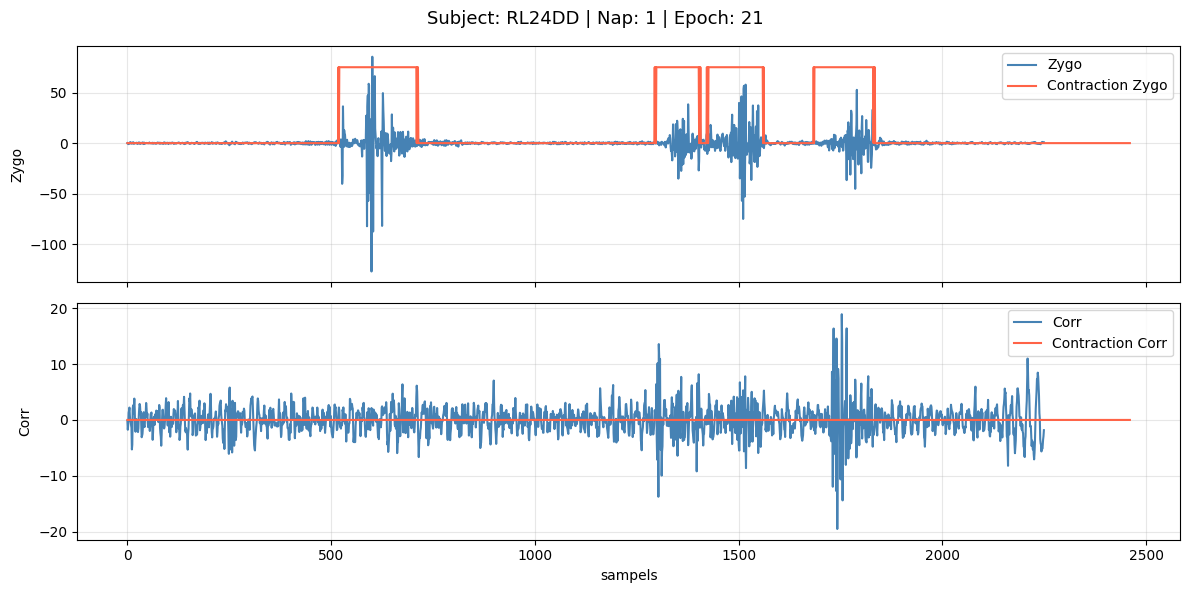

In [402]:
# plotting sanity check 
idx = k
plot_random_epoch(features_all,subject=subj_test.iloc[idx],epoch=epoch_test.iloc[idx],nap_id=int(nap_test.iloc[idx]),random=False) # set random to false to input subject, nap and epoch you want to check 

### Calling function for training 

In [19]:
epoch_num = 10 
num_classes = 2 # binary classification at each time step 
feature_num = 1
input_shape = 2248

In [ ]:
tf.keras.backend.clear_session()

results_segmentation = run_kfold_training(
    model_func=unet_1d,
    X_train_full=X_train_full[:, :input_shape, :],
    X=X[:, :input_shape, :],
    y=to_one_hot(y[:, 0, :input_shape, np.newaxis]), # add one hot function when calling segmentation
    input_shape=input_shape, # to make divisible by 4 
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": "categorical_crossentropy",# "binary_crossentropy" use for single neuron 
        "metrics": ["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    },
    fit_kwargs={"epochs": 10},
    n_splits=5)

Fold: 1 =================================================================
Epoch 1/10
286/286 [==============================] - 143s 395ms/step - loss: 0.2565 - accuracy: 0.9595 - precision: 0.9595 - recall: 0.9595 - val_loss: 0.1913 - val_accuracy: 0.9635 - val_precision: 0.9635 - val_recall: 0.9635
Epoch 2/10
286/286 [==============================] - 147s 513ms/step - loss: 0.1832 - accuracy: 0.9626 - precision: 0.9626 - recall: 0.9626 - val_loss: 0.1744 - val_accuracy: 0.9635 - val_precision: 0.9635 - val_recall: 0.9635
Epoch 3/10
286/286 [==============================] - 120s 420ms/step - loss: 0.1709 - accuracy: 0.9626 - precision: 0.9626 - recall: 0.9626 - val_loss: 0.1646 - val_accuracy: 0.9636 - val_precision: 0.9636 - val_recall: 0.9636
Epoch 4/10
286/286 [==============================] - 112s 390ms/step - loss: 0.1654 - accuracy: 0.9627 - precision: 0.9627 - recall: 0.9627 - val_loss: 0.1622 - val_accuracy: 0.9635 - val_precision: 0.9635 - val_recall: 0.9635
Epoch 5/10
286

ValueError: in user code:

    File "/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1151, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/engine/training.py", line 1209, in compute_loss
        return self.compiled_loss(
    File "/User

In [ ]:
model_segmentation = results_segmentation["models"][-1]
model_history_segmentation = model_segmentation.fit(X_train_full[:, :input_shape, :], to_one_hot(y_train_full[:, 0, :input_shape, np.newaxis]), epochs=epoch_num, validation_data=(np.array(X_test[:, :2248, :], dtype=np.float32), to_one_hot(np.array(y_test[:, 0, :2248, np.newaxis], dtype=np.float32)))) #, callbacks=[early_stop])

Epoch 1/10


2026-05-29 00:42:02.129419: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


357/357 [==============================] - 158s 396ms/step - loss: 0.0955 - accuracy: 0.9714 - precision: 0.9714 - recall: 0.9714 - val_loss: 0.0952 - val_accuracy: 0.9718 - val_precision: 0.9718 - val_recall: 0.9718
Epoch 2/10
357/357 [==============================] - 22243s 62s/step - loss: 0.0903 - accuracy: 0.9725 - precision: 0.9725 - recall: 0.9725 - val_loss: 0.0872 - val_accuracy: 0.9733 - val_precision: 0.9733 - val_recall: 0.9733
Epoch 3/10
357/357 [==============================] - 126s 353ms/step - loss: 0.0896 - accuracy: 0.9726 - precision: 0.9726 - recall: 0.9726 - val_loss: 0.0877 - val_accuracy: 0.9729 - val_precision: 0.9729 - val_recall: 0.9729
Epoch 4/10
357/357 [==============================] - 195s 546ms/step - loss: 0.0877 - accuracy: 0.9729 - precision: 0.9729 - recall: 0.9729 - val_loss: 0.0869 - val_accuracy: 0.9736 - val_precision: 0.9736 - val_recall: 0.9736
Epoch 5/10
357/357 [==============================] - 121s 337ms/step - loss: 0.0875 - accuracy: 0.

In [21]:
import pickle

# Save
with open('model_segmentation_2neuronn_2905.pkl', 'wb') as f:
    pickle.dump(model_segmentation, f)

## Results and Testing 

### K-means Results

In [71]:
with open("model_segmentation_v2.pkl", "rb") as f:
    model_segmentation = pickle.load(f)

In [172]:
with open("model_segmentation_2neuronn.pkl", "rb") as f:
    model_segmentation_2n = pickle.load(f)

In [17]:
cvScores = results_segmentation["cv_scores"]
for metric in ['accuracy', 'loss']:
    vals = [s[metric] for s in cvScores]
    print(f"{metric}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

accuracy: 0.9629 ± 0.0004
loss: 0.1588 ± 0.0015


### Testing - Accuracy and F1

In [173]:
input_shape = 2248
y_pred_train_2n = model_segmentation_2n.predict(X_train_full[:, :input_shape, :])  
y_pred_test_2n = model_segmentation_2n.predict(np.array(X_test[:, :input_shape, :], dtype=np.float32))  

y_pred_train_labels = np.argmax(y_pred_train_2n, axis=-1, keepdims=True)  # (14280, 2248, 1)
y_pred_test_labels  = np.argmax(y_pred_test_2n,  axis=-1, keepdims=True)  
#print(iou_metric(y_true, y_pred_train, threshold=0.5))
#print(iou_metric(y_true, y_pred_test, threshold=0.5))

90/90 [==============================] - 8s 72ms/step


In [72]:
input_shape = 2248
y_pred_train = model_segmentation.predict(X_train_full[:, :input_shape, :])  
y_pred_test = model_segmentation.predict(np.array(X_test[:, :input_shape, :], dtype=np.float32))  

y_pred_train_labels = np.argmax(y_pred_train, axis=-1, keepdims=True)  # (14280, 2248, 1)
y_pred_test_labels  = np.argmax(y_pred_test,  axis=-1, keepdims=True)  
#print(iou_metric(y_true, y_pred_train, threshold=0.5))
#print(iou_metric(y_true, y_pred_test, threshold=0.5))

90/90 [==============================] - 7s 70ms/step


## Plotting

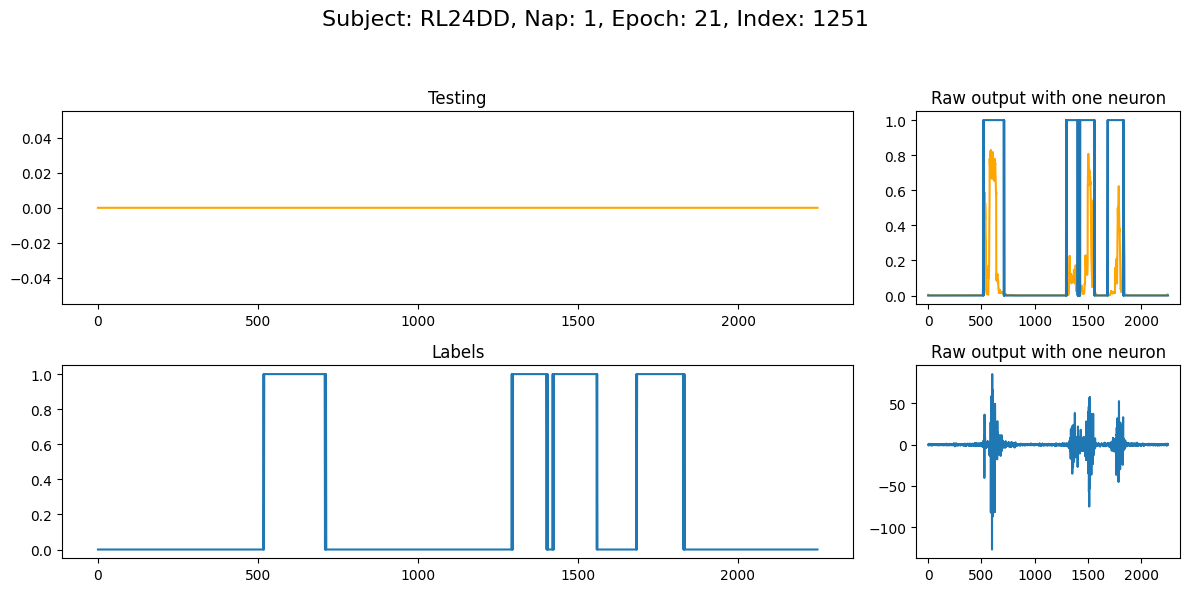

In [401]:
i = random.randint(0, np.shape(y_pred_train_labels)[0])
k = random.randint(0, 2856)

'''
b = plt.plot(y_train_full[:,0][:,:input_shape][i,:],label="labels")
a = plt.plot(y_pred_train.squeeze()[i,:],label="prediction training")
plt.ylim(0,1)
plt.legend()
plt.show()
''' 
y_true = y_pred_test_labels.squeeze()[k,:].copy()
#y_true = (y_true > 0.6).astype(int)
#y_true = uniform_filter1d(y_true, size=20)  

#d = plt.plot(X_test[k,:input_shape,:].squeeze(),label="contraction")


fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 6),
    gridspec_kw={'width_ratios': [3, 1]}  # optional
)

# Existing plots
axs[0, 0].plot(y_true,color="orange",label="prediction testing")
axs[0, 0].set_title("Testing")

axs[1, 0].plot(y_test[:,0][:,:input_shape][k,:],label="labels")
axs[1, 0].set_title("Labels")

# New subplot on the right
axs[0, 1].plot(y_pred_test.squeeze()[k,:].copy(),color="orange",label="prediction testing")
axs[0,1].plot(y_test[:,0][:,:input_shape][k,:],label="labels")
axs[0, 1].set_title("Third Plot")
axs[0, 1].set_title("Raw output with one neuron")

#axs[1, 1].plot(y_pred_test.squeeze()[k,:].copy(),color="orange",label="prediction testing")
axs[1,1].plot(X_test[k,:,:],label="labels")
axs[1, 1].set_title("Time series")

# Optionally leave bottom-right empty

fig.suptitle(f"Subject: {subject[idx_test].iloc[k]}, Nap: {np.array(nap)[idx_test][k]}, Epoch: {np.array(epoch)[idx_test][k]}, Index: {k}", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

#b = plt.plot(y_test[:,0][:,:input_shape][k,:],label="labels")
#c = plt.plot(y_true,label="prediction testing")

 

In [ ]:
with open('model_segmentation.pickle', 'wb') as handle:
    pickle.dump(model_segmentation, handle)

## Bad Code?

In [ ]:
corr_mask = muscle_test == "Corr"
zygo_mask = muscle_test == "Zygo"

corr_mask_tr = muscle_train == "Corr"
zygo_mask_tr = muscle_train == "Zygo"

# full train

y_pred_train = model_segmentation.predict(X_train_full[:, :input_shape, :])  
y_pred_test = model_segmentation.predict(np.array(X_test[:, :2248, :], dtype=np.float32))  
 
# Calculate accuracy
accuracy_training = accuracy_score(y_train_full[:,0][:,:input_shape], y_pred_train)   
accuracy_tes = accuracy_score(y_test[:,0], y_pred_train)  

accuracy_training_zygo = accuracy_score(y_train_full[:,0][:,:input_shape][zygo_mask_tr], y_pred_train[zygo_mask_tr])   
accuracy_test_zygo = accuracy_score(y_test[:,0][:,:input_shape][zygo_mask], y_pred_train[zygo_mask])  

accuracy_training_corr = accuracy_score(y_train_full[:,0][:,:input_shape][corr_mask_tr], y_pred_train[corr_mask_tr])   
accuracy_test_corr = accuracy_score(y_test[:,0][:,:input_shape][corr_mask], y_pred_train[corr_mask] ) 

# Calculate F1 score
f1_training = f1_score(y_train_full[:,0][:,:input_shape], y_pred_train, average='weighted')  
f1_test = f1_score(y_test[:,0][:,:input_shape], y_pred_train, average='weighted')  

f1_training_zygo = f1_score(y_train_full[:,0][:,:input_shape][zygo_mask_tr], y_pred_train[zygo_mask_tr], average='weighted')   
f1_test_zygo = f1_score(y_test[:,0][:,:input_shape][zygo_mask], y_pred_train[zygo_mask], average='weighted')  

f1_training_corr = f1_score(y_train_full[:,0][:,:input_shape][corr_mask_tr], y_pred_train[corr_mask_tr], average='weighted')   
f1_test_corr = f1_score(y_test[:,0][[:,:input_shape]corr_mask], y_pred_train[corr_mask], average='weighted') 


# Print accuracy and F1 score
print("Corru Scores------------------------------")  
print("Training Accuracy :", accuracy_training_corr) 
print("Test Accuracy :", accuracy_test_corr)  
print("Training F1 Score :", f1_training_corr)  
print("Test F1 Score :", f1_test_corr) 

print("Zygo Scores------------------------------")  
print("Training Accuracy :", accuracy_training_zygo)  
print("Test Accuracy :", accuracy_test_zygo)  
print("Training F1 Score :", f1_training_zygo)   
print("Test F1 Score :", f1_test_zygo)


### Plotting

In [ ]:
# one plot demonstrating labels against data 
# one plot showing calculated values against data 